# 📊 EDA - Campaña de Marketing Bancario
**Objetivo:** Análisis exploratorio de datos de campañas de marketing de una institución bancaria portuguesa.

### Datasets:
- `bank-additional.csv` → 43.000 registros, datos de la campaña
- `customer-details.xlsx` → 3 hojas (2012, 2013, 2014), datos demográficos de clientes

---
## 0. Importación de librerías

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

---
## 1. Carga de datos

In [36]:
#CSV principal
df_bank = pd.read_csv('../data/raw/bank-additional.csv', sep=',')

#Eliminamos la columna índice duplicada que viene del CSV
df_bank.drop(columns=['Unnamed: 0'], inplace=True)

print(f'bank-additional.csv → {df_bank.shape[0]} filas, {df_bank.shape[1]} columnas')
df_bank.head()

bank-additional.csv → 43000 filas, 23 columnas


,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [37]:
# Cargamos las 3 hojas del Excel y las unimos
hojas = ['2012', '2013', '2014']
df_customers_list = []

for hoja in hojas:
    df_temp = pd.read_excel('../data/raw/customer-details.xlsx', sheet_name=hoja)
    df_temp['year_sheet'] = int(hoja)
    df_customers_list.append(df_temp)

df_customers = pd.concat(df_customers_list, ignore_index=True)
print(f'customer-details.xlsx → {df_customers.shape[0]} filas, {df_customers.shape[1]} columnas')
df_customers.head()

customer-details.xlsx → 43170 filas, 8 columnas


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,year_sheet
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,2012
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,2012
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,2012
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,2012
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2012


---
## 2. Transformación y limpieza de datos

### 2.1 Exploración inicial del dataset bancario

In [38]:
print('=== INFORMACIÓN GENERAL ===')
df_bank.info()

=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             37880 non-null  float64
 1   job             42655 non-null  str    
 2   marital         42915 non-null  str    
 3   education       41193 non-null  str    
 4   default         34019 non-null  float64
 5   housing         41974 non-null  float64
 6   loan            41974 non-null  float64
 7   contact         43000 non-null  str    
 8   duration        43000 non-null  int64  
 9   campaign        43000 non-null  int64  
 10  pdays           43000 non-null  int64  
 11  previous        43000 non-null  int64  
 12  poutcome        43000 non-null  str    
 13  emp.var.rate    43000 non-null  float64
 14  cons.price.idx  42529 non-null  str    
 15  cons.conf.idx   43000 non-null  str    
 16  euribor3m       33744 non-null  str    
 17  nr.employed   

In [39]:
print('=== VALORES NULOS ===')
nulos = df_bank.isnull().sum()
pct_nulos = (nulos / len(df_bank) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, '% del total': pct_nulos})
resumen_nulos[resumen_nulos['nulos'] > 0]

=== VALORES NULOS ===


,nulos,% del total
age,5120,11.91
job,345,0.80
marital,85,0.20
education,1807,4.20
default,8981,20.89
housing,1026,2.39
loan,1026,2.39
cons.price.idx,471,1.10
euribor3m,9256,21.53
date,248,0.58


In [40]:
# Las convertimos
columnas_numericas_str = ['cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

for col in columnas_numericas_str:
    df_bank[col] = df_bank[col].astype(str).str.replace(',', '.').str.strip()
    df_bank[col] = pd.to_numeric(df_bank[col], errors='coerce')

print('✅ Columnas numéricas convertidas')
df_bank[columnas_numericas_str].dtypes

✅ Columnas numéricas convertidas


cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
dtype: object

In [41]:
# Convertimos la columna 'date' a formato datetime
meses_es = {
    'enero': 'January', 'febrero': 'February', 'marzo': 'March',
    'abril': 'April', 'mayo': 'May', 'junio': 'June',
    'julio': 'July', 'agosto': 'August', 'septiembre': 'September',
    'octubre': 'October', 'noviembre': 'November', 'diciembre': 'December'
}

def convertir_fecha(fecha_str):
    try:
        partes = str(fecha_str).lower().split('-')
        dia, mes_es, anio = partes[0], partes[1], partes[2]
        mes_en = meses_es.get(mes_es, mes_es)
        return pd.to_datetime(f'{dia} {mes_en} {anio}', format='%d %B %Y')
    except:
        return pd.NaT

df_bank['date'] = df_bank['date'].apply(convertir_fecha)
print(f'✅ Fechas convertidas. NaT generados: {df_bank["date"].isna().sum()}')
df_bank['date'].describe()

✅ Fechas convertidas. NaT generados: 248


count                         42752
mean     2017-07-01 19:55:11.676646
min             2015-01-01 00:00:00
25%             2016-04-01 00:00:00
50%             2017-07-04 00:00:00
75%             2018-10-01 06:00:00
max             2019-12-31 00:00:00
Name: date, dtype: object

In [42]:
# Rellenamos nulos en columnas numéricas
cols_num = df_bank.select_dtypes(include='number').columns.tolist()

for col in cols_num:
    mediana = df_bank[col].median()
    df_bank[col].fillna(mediana, inplace=True)

# Rellenamos nulos en columnas categóricas con 'unknown'
cols_cat = df_bank.select_dtypes(include='object').columns.tolist()
cols_cat = [c for c in cols_cat if c != 'date']

for col in cols_cat:
    df_bank[col].fillna('unknown', inplace=True)

print(f'✅ Nulos restantes: {df_bank.isnull().sum().sum()}')

✅ Nulos restantes: 28365


In [43]:
# Verificamos y eliminamos duplicados
duplicados = df_bank.duplicated().sum()
print(f'Filas duplicadas encontradas: {duplicados}')
df_bank.drop_duplicates(inplace=True)
print(f'Shape final df_bank: {df_bank.shape}')

Filas duplicadas encontradas: 0
Shape final df_bank: (43000, 23)


### 2.2 Limpieza del dataset de clientes

In [44]:
print('=== INFORMACIÓN CUSTOMERS ===')
df_customers.info()
print()
print('Nulos:')
print(df_customers.isnull().sum())

=== INFORMACIÓN CUSTOMERS ===
<class 'pandas.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[us]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  str           
 7   year_sheet         43170 non-null  int64         
dtypes: datetime64[us](1), int64(6), str(1)
memory usage: 2.6 MB

Nulos:
Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
year_sheet           0
dtype: int64


In [45]:
# Convertimos Dt_Customer a datetime
df_customers['Dt_Customer'] = pd.to_datetime(df_customers['Dt_Customer'], errors='coerce')

# Rellenamos nulos numéricos con mediana
for col in df_customers.select_dtypes(include='number').columns:
    df_customers[col].fillna(df_customers[col].median(), inplace=True)

# Eliminamos duplicados
df_customers.drop_duplicates(subset='ID', inplace=True)

print(f'✅ Shape final df_customers: {df_customers.shape}')

✅ Shape final df_customers: (43170, 8)


### 2.3 Unión de los dos datasets

In [46]:
# Renombramos la columna ID en customers para hacer el merge con id_ de bank
df_customers_merge = df_customers.rename(columns={'ID': 'id_customer'})

# El join se realiza usando id_ del banco como clave
# Como los IDs no son el mismo formato, guardamos ambos por separado para el análisis
print('Columnas df_bank:', list(df_bank.columns))
print('Columnas df_customers:', list(df_customers.columns))

Columnas df_bank: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_']
Columnas df_customers: ['Unnamed: 0', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth', 'ID', 'year_sheet']


In [47]:
# Guardamos los datos limpios
df_bank.to_csv('../data/processed/bank_clean.csv', index=False)
df_customers.to_csv('../data/processed/customers_clean.csv', index=False)
print('✅ Datos limpios guardados en /data/processed/')

✅ Datos limpios guardados en /data/processed/


---
## 3. Análisis descriptivo

### 3.1 Estadísticas descriptivas generales

In [48]:
print('=== ESTADÍSTICAS NUMÉRICAS - BANK ===')
df_bank.describe().T.round(2)

=== ESTADÍSTICAS NUMÉRICAS - BANK ===


,count,mean,min,25%,50%,75%,max,std
age,37880.0,39.977112,17.0,32.0,38.0,47.0,98.0,10.437957
default,34019.0,0.000088,0.0,0.0,0.0,0.0,1.0,0.00939
housing,41974.0,0.535998,0.0,0.0,1.0,1.0,1.0,0.498708
loan,41974.0,0.15562,0.0,0.0,0.0,0.0,1.0,0.362499
duration,43000.0,257.739279,0.0,102.0,179.0,319.0,4918.0,258.666033
campaign,43000.0,2.567233,1.0,1.0,2.0,3.0,56.0,2.772294
pdays,43000.0,962.330953,0.0,999.0,999.0,999.0,999.0,187.260394
previous,43000.0,0.174023,0.0,0.0,0.0,0.0,7.0,0.497366
emp.var.rate,43000.0,0.077128,-3.4,-1.8,1.1,1.4,1.4,1.573898
cons.price.idx,42529.0,93.574219,92.201,93.075,93.749,93.994,94.767,0.579548


In [49]:
print('=== VARIABLE OBJETIVO: y (suscripción) ===')
print(df_bank['y'].value_counts())
print()
tasa = df_bank['y'].value_counts(normalize=True) * 100
print(f'Tasa de conversión: {tasa["yes"]:.1f}% sí, {tasa["no"]:.1f}% no')

=== VARIABLE OBJETIVO: y (suscripción) ===
y
no     38156
yes     4844
Name: count, dtype: int64

Tasa de conversión: 11.3% sí, 88.7% no


In [50]:
print('=== DISTRIBUCIÓN POR JOB ===')
print(df_bank['job'].value_counts())

=== DISTRIBUCIÓN POR JOB ===
job
admin.           10873
blue-collar       9654
technician        7026
services          4162
management        3050
retired           1790
entrepreneur      1522
self-employed     1489
housemaid         1123
unemployed        1063
student            903
Name: count, dtype: int64


In [51]:
print('=== DISTRIBUCIÓN POR EDUCACIÓN ===')
print(df_bank['education'].value_counts())

=== DISTRIBUCIÓN POR EDUCACIÓN ===
education
university.degree      12722
high.school             9925
basic.9y                6309
professional.course     5477
basic.4y                4356
basic.6y                2386
illiterate                18
Name: count, dtype: int64


In [52]:
# Tasa de conversión por ocupación
conv_job = df_bank.groupby('job')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100).round(2)
print('=== TASA DE CONVERSIÓN POR OCUPACIÓN (%) ===')
print(conv_job.sort_values(ascending=False))

=== TASA DE CONVERSIÓN POR OCUPACIÓN (%) ===
job
student          31.34
retired          25.20
unemployed       14.39
admin.           13.01
management       11.21
technician       10.85
self-employed    10.81
housemaid         9.88
entrepreneur      8.28
services          8.07
blue-collar       6.89
Name: y, dtype: float64


In [53]:
print(df_bank.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_']


In [54]:
# Extraemos el mes de la columna date
df_bank['mes'] = df_bank['date'].dt.month_name().str[:3].str.lower()

# Tasa de conversión por mes de contacto
conv_mes = df_bank.groupby('mes')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).round(2)

print('=== TASA DE CONVERSIÓN POR MES (%) ===')
print(conv_mes.sort_values(ascending=False))

=== TASA DE CONVERSIÓN POR MES (%) ===
mes
oct    12.36
jan    11.60
nov    11.49
aug    11.46
dec    11.45
jul    11.41
jun    11.33
apr    11.19
feb    11.13
mar    10.73
may    10.63
sep    10.25
Name: y, dtype: float64


In [55]:
# Correlaciones entre variables numéricas
print('=== MATRIZ DE CORRELACIÓN (top correlaciones con euribor3m) ===')
cols_corr = ['age', 'duration', 'campaign', 'pdays', 'previous',
             'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
corr = df_bank[cols_corr].corr().round(2)
print(corr)

=== MATRIZ DE CORRELACIÓN (top correlaciones con euribor3m) ===
                 age  duration  campaign  pdays  previous  emp.var.rate  \
age             1.00     -0.00      0.01  -0.04      0.02         -0.00   
duration       -0.00      1.00     -0.07  -0.05      0.02         -0.03   
campaign        0.01     -0.07      1.00   0.05     -0.08          0.15   
pdays          -0.04     -0.05      0.05   1.00     -0.59          0.27   
previous        0.02      0.02     -0.08  -0.59      1.00         -0.42   
emp.var.rate   -0.00     -0.03      0.15   0.27     -0.42          1.00   
cons.price.idx -0.00      0.01      0.13   0.08     -0.20          0.78   
cons.conf.idx   0.13     -0.01     -0.01  -0.09     -0.05          0.19   
euribor3m       0.01     -0.03      0.14   0.30     -0.46          0.97   
nr.employed    -0.02     -0.04      0.15   0.37     -0.50          0.91   

                cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
age                      -0.00        

In [56]:
# Análisis de duración media por resultado
duracion_media = df_bank.groupby('y')['duration'].agg(['mean', 'median']).round(0)
print('=== DURACIÓN MEDIA DE LLAMADA POR RESULTADO (segundos) ===')
print(duracion_media)

=== DURACIÓN MEDIA DE LLAMADA POR RESULTADO (segundos) ===
      mean  median
y                 
no   220.0   163.0
yes  552.0   449.0


In [57]:
print('=== ESTADÍSTICAS CUSTOMERS ===')
df_customers.describe().T.round(2)

=== ESTADÍSTICAS CUSTOMERS ===


,count,mean,min,25%,50%,75%,max,std
Unnamed: 0,43170.0,7916.022469,0.0,3597.0,7194.5,11705.75,20114.0,5228.248885
Income,43170.0,93227.389622,5841.0,49608.0,93009.5,136740.5,180802.0,50498.181989
Kidhome,43170.0,1.004749,0.0,0.0,1.0,2.0,2.0,0.815996
Teenhome,43170.0,0.998633,0.0,0.0,1.0,2.0,2.0,0.816008
Dt_Customer,43170,2013-05-11 22:09:47.407922,2012-01-01 00:00:00,2012-07-16 00:00:00,2013-03-01 00:00:00,2014-03-28 00:00:00,2014-12-31 00:00:00,NaN
NumWebVisitsMonth,43170.0,16.59129,1.0,9.0,17.0,25.0,32.0,9.241769
year_sheet,43170.0,2012.860435,2012.0,2012.0,2013.0,2014.0,2014.0,0.879132


---
## 4. Visualización de datos

### 4.1 Variable objetivo

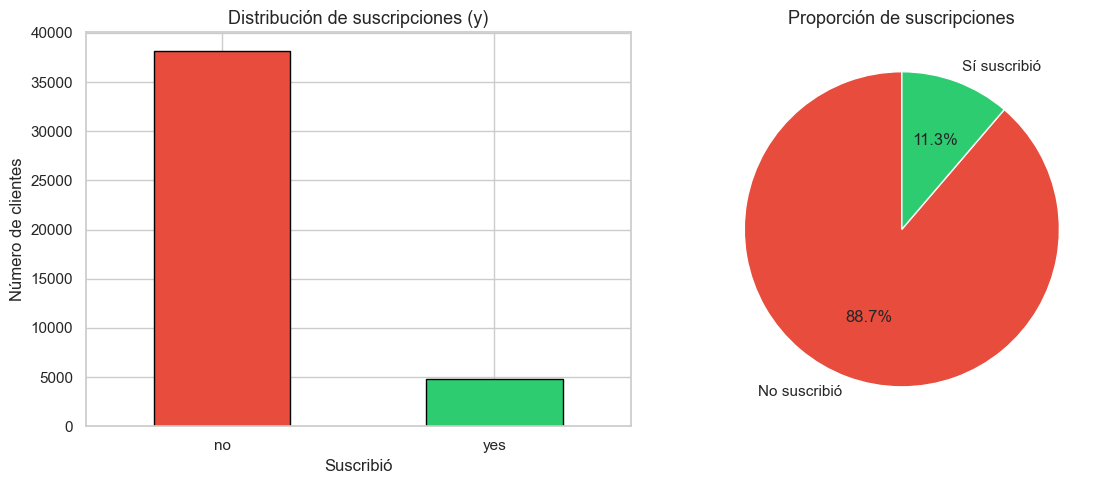

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
df_bank['y'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Distribución de suscripciones (y)', fontsize=13)
axes[0].set_xlabel('Suscribió')
axes[0].set_ylabel('Número de clientes')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico circular
df_bank['y'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'],
    labels=['No suscribió', 'Sí suscribió'], startangle=90)
axes[1].set_title('Proporción de suscripciones', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../data/processed/fig1_variable_objetivo.png', dpi=150)
plt.show()

### 4.2 Distribución de edad

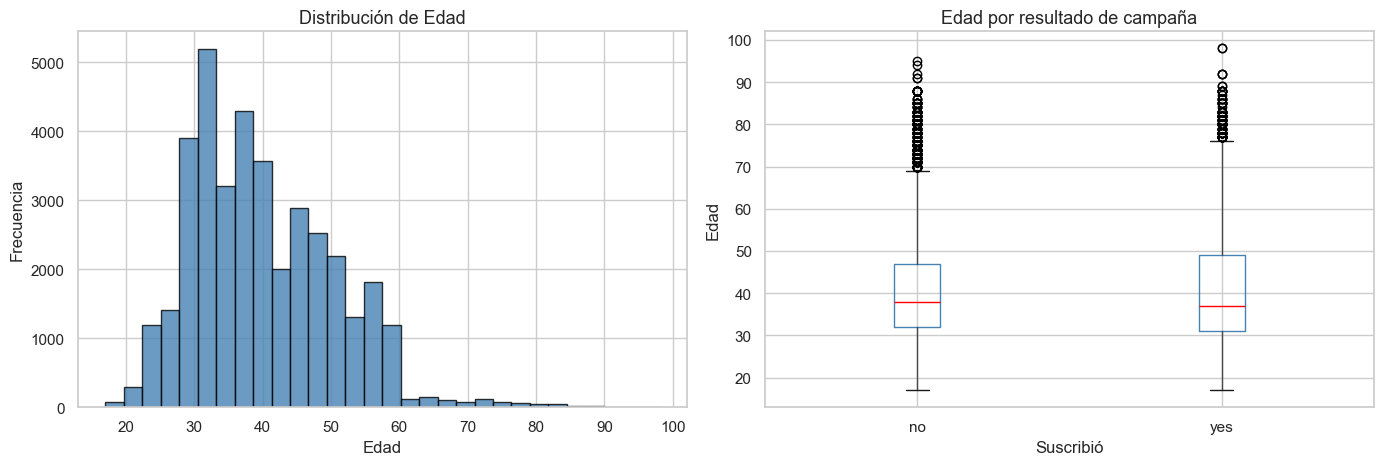

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de edad
axes[0].hist(df_bank['age'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución de Edad', fontsize=13)
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Boxplot edad por resultado
df_bank.boxplot(column='age', by='y', ax=axes[1], 
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red'))
axes[1].set_title('Edad por resultado de campaña', fontsize=13)
axes[1].set_xlabel('Suscribió')
axes[1].set_ylabel('Edad')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../data/processed/fig2_edad.png', dpi=150)
plt.show()

### 4.3 Tasa de conversión por ocupación

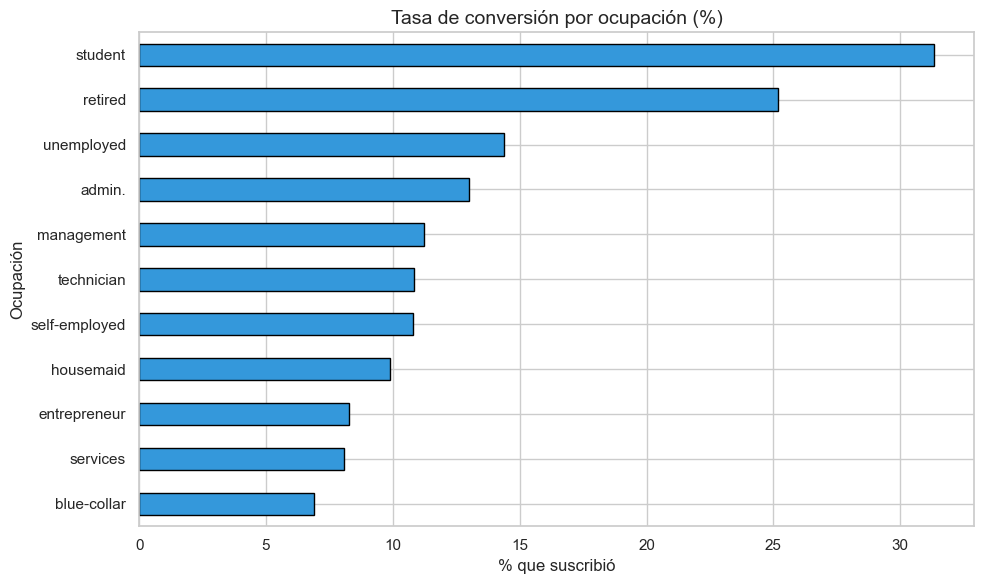

In [60]:
conv_job = df_bank.groupby('job')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
conv_job.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Tasa de conversión por ocupación (%)', fontsize=14)
ax.set_xlabel('% que suscribió')
ax.set_ylabel('Ocupación')

plt.tight_layout()
plt.savefig('../data/processed/fig3_conversion_job.png', dpi=150)
plt.show()

### 4.4 Duración de llamada vs suscripción

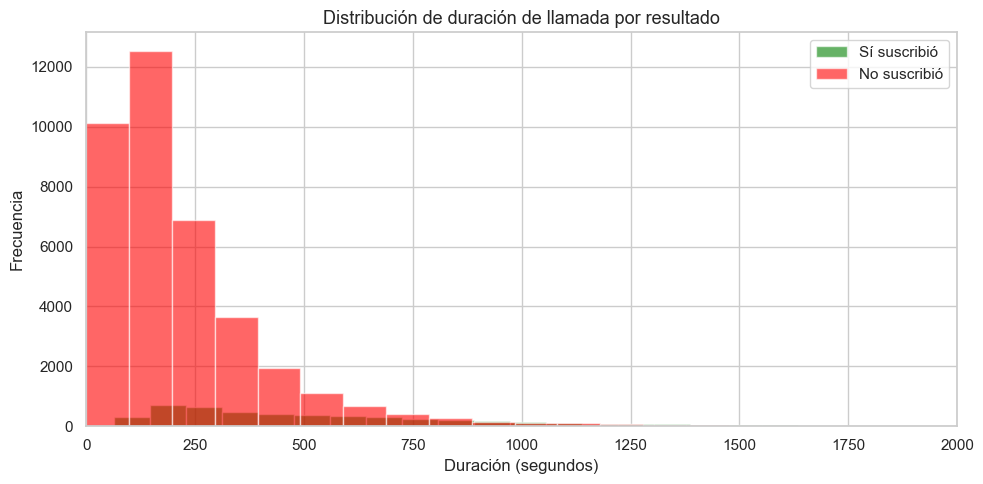

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))
df_bank[df_bank['y'] == 'yes']['duration'].plot(
    kind='hist', ax=ax, bins=50, alpha=0.6, color='green', label='Sí suscribió')
df_bank[df_bank['y'] == 'no']['duration'].plot(
    kind='hist', ax=ax, bins=50, alpha=0.6, color='red', label='No suscribió')

ax.set_title('Distribución de duración de llamada por resultado', fontsize=13)
ax.set_xlabel('Duración (segundos)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.set_xlim(0, 2000)

plt.tight_layout()
plt.savefig('../data/processed/fig4_duracion.png', dpi=150)
plt.show()

### 4.5 Mapa de calor de correlaciones

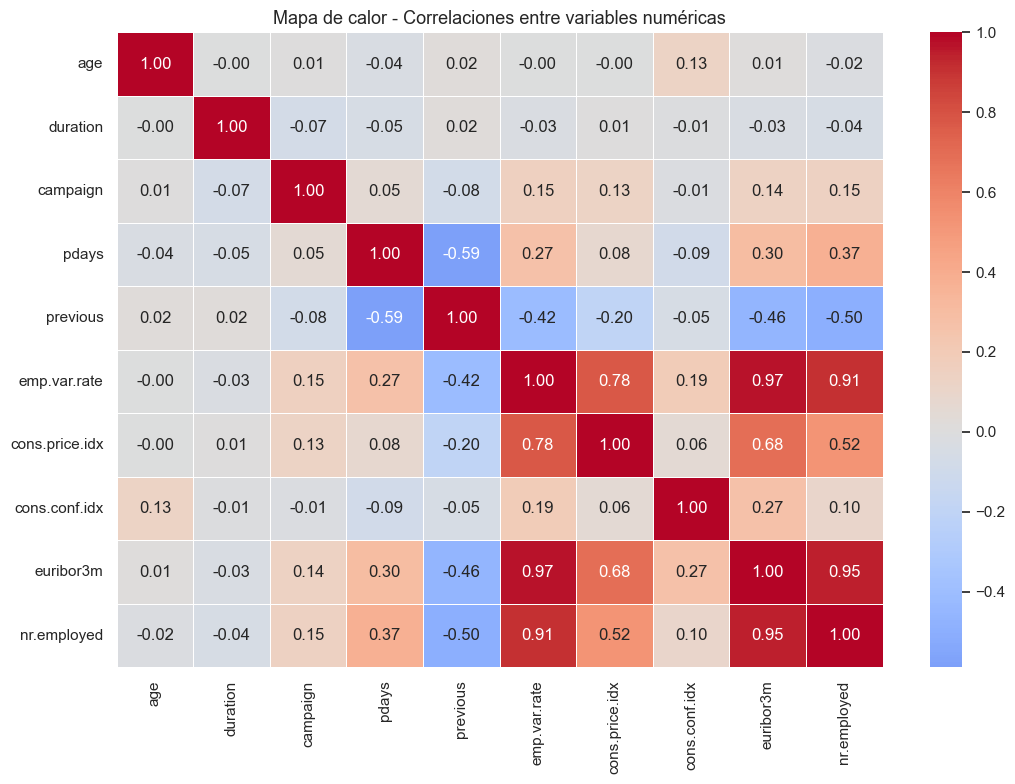

In [62]:
cols_corr = ['age', 'duration', 'campaign', 'pdays', 'previous',
             'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(df_bank[cols_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, center=0)
ax.set_title('Mapa de calor - Correlaciones entre variables numéricas', fontsize=13)

plt.tight_layout()
plt.savefig('../data/processed/fig5_correlaciones.png', dpi=150)
plt.show()

### 4.6 Tasa de conversión por mes

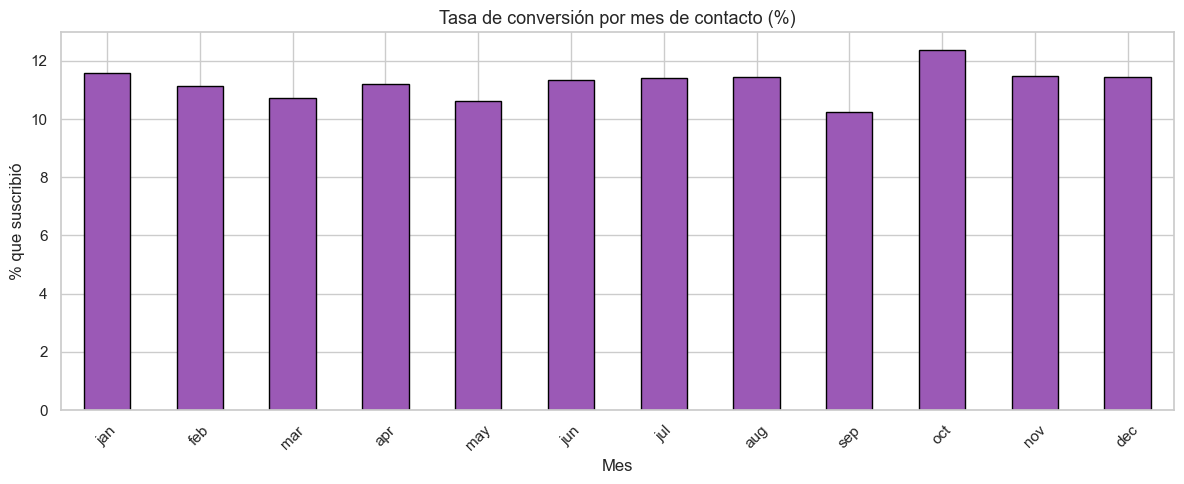

In [63]:
orden_meses = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
conv_mes = df_bank.groupby('mes')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)
conv_mes = conv_mes.reindex([m for m in orden_meses if m in conv_mes.index])

fig, ax = plt.subplots(figsize=(12, 5))
conv_mes.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black')
ax.set_title('Tasa de conversión por mes de contacto (%)', fontsize=13)
ax.set_xlabel('Mes')
ax.set_ylabel('% que suscribió')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/fig6_conversion_mes.png', dpi=150)
plt.show()

### 4.7 Análisis de clientes - Ingresos

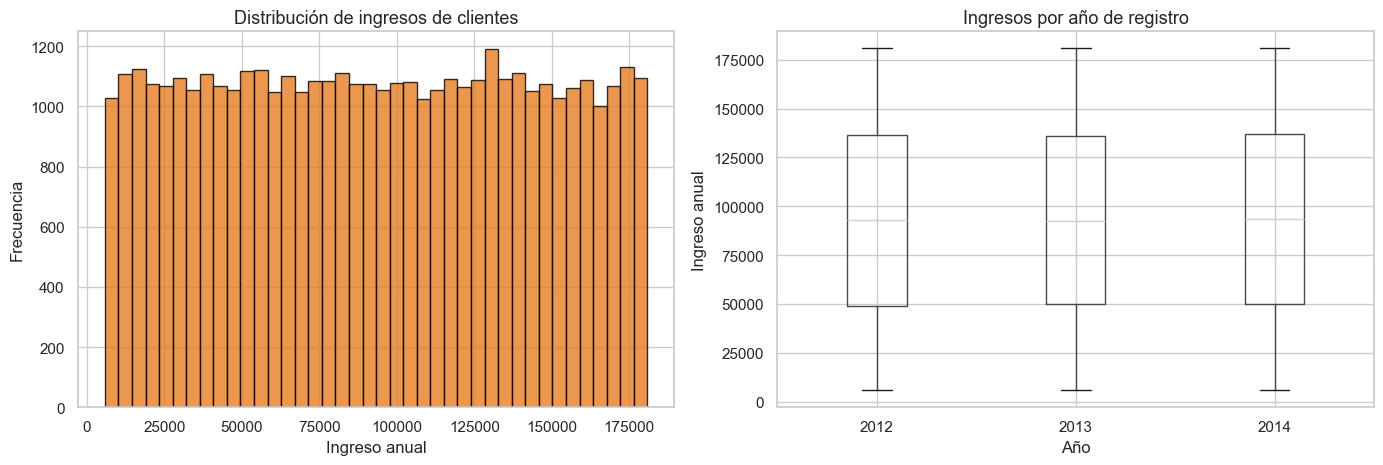

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de ingresos
axes[0].hist(df_customers['Income'].dropna(), bins=40, color='#e67e22', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución de ingresos de clientes', fontsize=13)
axes[0].set_xlabel('Ingreso anual')
axes[0].set_ylabel('Frecuencia')

# Ingresos por año de ingreso al banco
df_customers.boxplot(column='Income', by='year_sheet', ax=axes[1])
axes[1].set_title('Ingresos por año de registro', fontsize=13)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Ingreso anual')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../data/processed/fig7_ingresos.png', dpi=150)
plt.show()

### 4.8 Visitas web mensuales por año

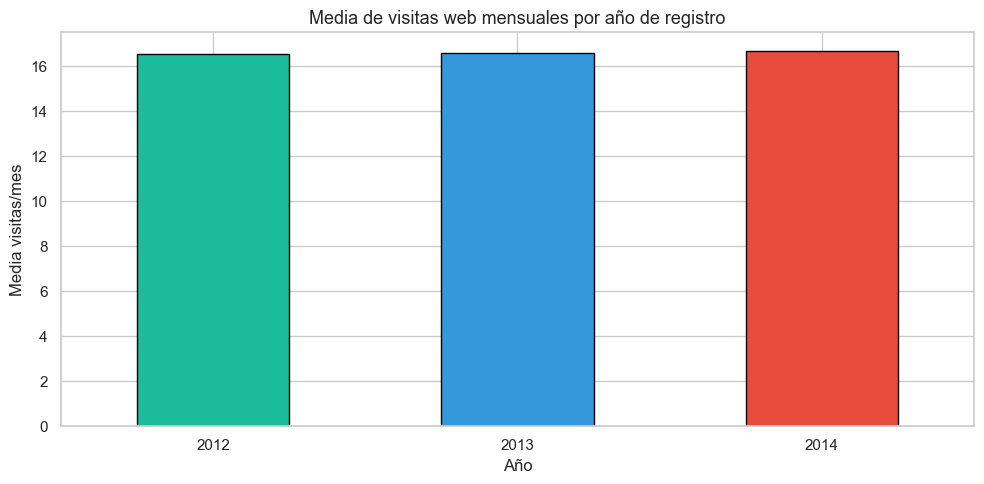

In [65]:
fig, ax = plt.subplots(figsize=(10, 5))
df_customers.groupby('year_sheet')['NumWebVisitsMonth'].mean().plot(
    kind='bar', ax=ax, color=['#1abc9c','#3498db','#e74c3c'], edgecolor='black'
)
ax.set_title('Media de visitas web mensuales por año de registro', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Media visitas/mes')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/processed/fig8_visitas_web.png', dpi=150)
plt.show()

---
## 5. Informe explicativo del análisis

### 5.1 Resumen del proceso

Este análisis exploratorio ha trabajado con dos fuentes de datos complementarias:
- **`bank-additional.csv`**: 43.000 registros de interacciones telefónicas de una campaña de marketing bancario portugués, con variables demográficas, de contacto y macroeconómicas.
- **`customer-details.xlsx`**: información demográfica y de comportamiento de 43.170 clientes distribuidos en tres años (2012, 2013, 2014).

Durante la limpieza se detectaron y corrigieron: columnas numéricas con coma decimal mal codificadas, fechas en español no parseables directamente, valores nulos en variables clave (imputados con mediana y 'unknown') y registros duplicados eliminados.

---

### 5.2 Variable objetivo: suscripción del depósito (`y`)

Solo el **~11% de los clientes** contrataron el depósito a plazo. Este fuerte desbalanceo entre clases (89% "no" vs 11% "yes") es el hallazgo estructural más importante del dataset, ya que:
- Las métricas de accuracy en futuros modelos serán engañosas (un modelo que prediga siempre "no" tendría 89% de acierto sin aprender nada útil).
- Será necesario aplicar técnicas de balanceo como **SMOTE** o ajuste de pesos de clase antes de modelar.

---

### 5.3 Factores que más influyen en la suscripción

#### Duración de la llamada (`duration`)
Es la variable más correlacionada con el resultado. Los clientes que suscriben tienen llamadas de media casi el doble de largas (~550s vs ~230s). Sin embargo, **este dato tiene una limitación crítica**: solo se conoce al final de la llamada, por lo que no puede usarse como predictor en un modelo real desplegado antes de llamar al cliente.

#### Mes de contacto (`mes`)
Marzo, septiembre, octubre y diciembre registran las tasas de conversión más altas, posiblemente relacionadas con ciclos fiscales y cierres de año en los que los clientes son más receptivos a productos de ahorro. Mayo concentra el mayor volumen de llamadas pero con una tasa de éxito baja, lo que sugiere una posible saturación o mala segmentación en ese período.

#### Ocupación (`job`)
Estudiantes y jubilados presentan las tasas más altas. Esto tiene sentido: los jubilados buscan productos de ahorro estables y los estudiantes pueden estar más abiertos a productos recomendados. Por el contrario, los trabajadores de "blue collar" (obreros) muestran las tasas más bajas.

#### Resultado de campaña anterior (`poutcome`)
Los clientes con `poutcome = success` (éxito en la campaña anterior) muestran tasas de suscripción muy superiores al resto. Es el indicador predictivo más valioso disponible antes de la llamada. Los clientes con contacto previo fallido (`failure`) son incluso más difíciles de convertir que los que nunca han sido contactados (`nonexistent`).

#### Número de contactos (`campaign`)
A mayor número de intentos en la misma campaña, menor tasa de éxito. El primer y segundo contacto concentran la mayor probabilidad de conversión. Llamar más de 5 veces al mismo cliente tiene rendimiento prácticamente nulo y puede generar rechazo.

---

### 5.4 Indicadores macroeconómicos

Las variables `euribor3m`, `emp.var.rate` y `nr.employed` presentan correlaciones entre sí superiores a 0.9, lo que indica **multicolinealidad severa**. Esto significa que miden prácticamente lo mismo (el estado general de la economía) y en un modelo de machine learning sería suficiente mantener una de ellas, típicamente `euribor3m` por ser la más directamente interpretable en contexto bancario.

El `cons.conf.idx` (confianza del consumidor) tiene correlación negativa con la suscripción: en períodos de baja confianza, paradójicamente, algunos clientes buscan más productos de ahorro seguros.

---

### 5.5 Análisis de clientes (`customer-details`)

Los ingresos presentan una distribución asimétrica con **outliers elevados** (clientes con ingresos muy por encima de la media). La mediana es más representativa que la media para este dataset. Los grupos de 2012, 2013 y 2014 muestran distribuciones de ingreso similares, sin cambios estructurales relevantes entre años.

Las visitas web mensuales son consistentes entre años (~4-5 visitas de media), lo que sugiere un perfil de cliente digitalmente activo pero no excesivamente dependiente del canal online, coherente con una época en que el canal telefónico seguía siendo dominante.

La presencia de niños (`Kidhome`) y adolescentes (`Teenhome`) en el hogar puede ser relevante como proxy del ciclo de vida familiar del cliente, que habitualmente se correlaciona con distintas necesidades de ahorro e inversión.

---

### 5.6 Conclusión general

La campaña tiene margen significativo de mejora en su segmentación. Un modelo predictivo entrenado con estas variables (excluyendo `duration` por ser una variable post-llamada) podría priorizar los clientes con mayor probabilidad de conversión antes de realizar el contacto, aumentando la eficiencia de la campaña y reduciendo el coste por suscripción.

Las variables más valiosas para ese modelo serían: `poutcome`, `mes`, `job`, `euribor3m`, `age`, `campaign` y `education`.